# Intersection rings for non-flat Tate resolutions and flavor symmetry enhancement in 5D SCFTs

This notebook ports the intersection-ring bookkeeping used in my publication https://arxiv.org/abs/2006.01694.

My PhD supervisor supplied a mathematica version of the code realized here prior to modifying and exetending it, and transcribing it into Python here.


## Mathematical reference points

The blowup notation is the one used in the Tate-form literature: a blowup `(x,y,z;e)` replaces the singular locus by an exceptional divisor `e=0`, introduces a projective relation, and performs the crepant proper transform. Reduced intersection matrices are defined by

\[
I_{ik}^{E_n}=D_{\alpha_i}^{E_n}\cdot D_{\alpha_i}^{E_n}\cdot S_k,
\]

and the flavor-curve criterion is the weighted condition

\[
\sum_k \xi_k\,S_k\cdot D_{\alpha_i}^2=-2.
\]



In [1]:
from __future__ import annotations

from collections import defaultdict, deque
from dataclasses import dataclass, field
from fractions import Fraction
from itertools import combinations
from typing import Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

pd.set_option("display.max_columns", 30)


## Sparse intersection-ring engine

The ambient Chow ring is represented by sparse polynomials in divisor classes.  Each section has a divisor class.  Each blowup adds one exceptional class and one projective relation.  Intersection numbers are computed by reducing the product of divisor classes against these projective relations and then integrating over the local base.

The local base convention used here is the one used in the Mathematica computations for these non-compact models:

\[
S_uS_v=1, \quad S_u^2=S_v^2=0, \quad E^2=-1, \quad E S_u=E S_v=0, \quad c_1=0.
\]


In [2]:
from __future__ import annotations
Monomial = Tuple[Tuple[str, int], ...]


def _norm_monomial(items: Iterable[Tuple[str, int]]) -> Monomial:
    d = defaultdict(int)
    for variable, power in items:
        if power:
            d[variable] += power
    return tuple(sorted((variable, power) for variable, power in d.items() if power))


def _mul_monomial(a: Monomial, b: Monomial) -> Monomial:
    return _norm_monomial(list(a) + list(b))


def _monomial_times_power(m: Monomial, variable: str, power: int) -> Monomial:
    return _mul_monomial(m, ((variable, power),) if power else ())


class Poly:
    """Sparse polynomial over Q, with variables represented by strings."""

    __slots__ = ("terms",)

    def __init__(self, terms: Optional[Dict[Monomial, Fraction]] = None):
        self.terms = {m: Fraction(c) for m, c in (terms or {}).items() if c}

    @staticmethod
    def zero() -> "Poly":
        return Poly({})

    @staticmethod
    def one() -> "Poly":
        return Poly({(): Fraction(1)})

    @staticmethod
    def const(c: int | Fraction) -> "Poly":
        c = Fraction(c)
        return Poly({(): c}) if c else Poly.zero()

    @staticmethod
    def var(name: str) -> "Poly":
        return Poly({((name, 1),): Fraction(1)})

    def __add__(self, other: "Poly" | int | Fraction) -> "Poly":
        other = as_poly(other)
        out = defaultdict(Fraction)
        out.update(self.terms)
        for monomial, coeff in other.terms.items():
            out[monomial] += coeff
        return Poly(out)

    def __radd__(self, other: "Poly" | int | Fraction) -> "Poly":
        return self + other

    def __neg__(self) -> "Poly":
        return Poly({m: -c for m, c in self.terms.items()})

    def __sub__(self, other: "Poly" | int | Fraction) -> "Poly":
        return self + (-as_poly(other))

    def __rsub__(self, other: "Poly" | int | Fraction) -> "Poly":
        return as_poly(other) - self

    def __mul__(self, other: "Poly" | int | Fraction) -> "Poly":
        other = as_poly(other)
        out = defaultdict(Fraction)
        for m1, c1 in self.terms.items():
            for m2, c2 in other.terms.items():
                out[_mul_monomial(m1, m2)] += c1 * c2
        return Poly(out)

    def __rmul__(self, other: "Poly" | int | Fraction) -> "Poly":
        return self * other

    def __truediv__(self, q: int | Fraction) -> "Poly":
        q = Fraction(q)
        if q == 0:
            raise ZeroDivisionError("division by zero in Poly")
        return Poly({m: c / q for m, c in self.terms.items()})

    def pow(self, n: int) -> "Poly":
        out = Poly.one()
        for _ in range(n):
            out *= self
        return out

    def degree(self, variable: str) -> int:
        if not self.terms:
            return -1
        return max(dict(m).get(variable, 0) for m in self.terms)

    def coefficient_exact(self, powers: Dict[str, int]) -> Fraction:
        return self.terms.get(_norm_monomial(powers.items()), Fraction(0))

    def coefficient_of_power(self, variable: str, power: int) -> "Poly":
        out = defaultdict(Fraction)
        for monomial, coeff in self.terms.items():
            powers = dict(monomial)
            if powers.get(variable, 0) == power:
                reduced = tuple((v, p) for v, p in monomial if v != variable)
                out[reduced] += coeff
        return Poly(out)

    def substitute_zero(self, variables: Iterable[str]) -> "Poly":
        variables = set(variables)
        out = {}
        for monomial, coeff in self.terms.items():
            if any(v in variables for v, _ in monomial):
                continue
            out[monomial] = coeff
        return Poly(out)

    def __repr__(self) -> str:
        return self.to_string()

    def to_string(self, max_terms: int = 20) -> str:
        if not self.terms:
            return "0"
        pieces = []
        for i, (monomial, coeff) in enumerate(sorted(self.terms.items())):
            if i >= max_terms:
                pieces.append(f"... + {len(self.terms) - max_terms} terms")
                break
            var_part = "*".join(v if p == 1 else f"{v}^{p}" for v, p in monomial)
            pieces.append(f"{coeff}" + (f"*{var_part}" if var_part else ""))
        return " + ".join(pieces)


def as_poly(x: Poly | int | Fraction) -> Poly:
    return x if isinstance(x, Poly) else Poly.const(x)


def substitute_linear(poly: Poly, replacements: Dict[str, Poly]) -> Poly:
    out = Poly.zero()
    for monomial, coeff in poly.terms.items():
        term = Poly.const(coeff)
        for variable, power in monomial:
            term *= replacements.get(variable, Poly.var(variable)).pow(power)
        out += term
    return out


@dataclass(frozen=True)
class ProjectiveRelation:
    # A projective relation stores coordinates as products of section names.
    # For example, after a blowup an old coordinate x may appear as the product x*e.
    coordinates: Tuple[Tuple[str, ...], ...]
    leading_class: str
    degree: int


@dataclass
class SparseHSV:
    """Hypersurface variety bookkeeping needed for intersection computations."""

    classes: Dict[str, Poly]
    projective_relations: List[ProjectiveRelation]
    hypersurface_class: Poly
    base_exceptionals: List[str] = field(default_factory=list)
    _relation_cache: Dict[Tuple, Optional[Poly]] = field(default_factory=dict)

    def class_of_factor(self, factor: str | Tuple[str, ...]) -> Poly:
        if isinstance(factor, str):
            if factor == "Y":
                return self.hypersurface_class
            return self.classes[factor]
        total = Poly.zero()
        for section in factor:
            total += self.classes[section]
        return total

    def _update_existing_projective_relations(self, center: Iterable[str], exceptional_section: str) -> None:
        center = set(center)
        updated = []
        for rel in self.projective_relations:
            new_coordinates = []
            for factor in rel.coordinates:
                new_factor = []
                for section in factor:
                    new_factor.append(section)
                    if section in center:
                        new_factor.append(exceptional_section)
                new_coordinates.append(tuple(new_factor))
            updated.append(ProjectiveRelation(tuple(new_coordinates), rel.leading_class, rel.degree))
        self.projective_relations = updated

    def blowup(self, sequence_item: Tuple[str, ...]) -> "SparseHSV":
        *center, exceptional = sequence_item
        exceptional_class = f"E_{exceptional}"
        codim = len(center)

        self._update_existing_projective_relations(center, exceptional)
        self.hypersurface_class -= (codim - 1) * Poly.var(exceptional_class)
        for section in center:
            self.classes[section] -= Poly.var(exceptional_class)
        self.classes[exceptional] = Poly.var(exceptional_class)
        self.projective_relations.append(
            ProjectiveRelation(tuple((section,) for section in center), exceptional_class, codim)
        )
        self._relation_cache.clear()
        return self

    def base_blowup(self, a: str = "u", b: str = "v", exceptional: str = "eps") -> "SparseHSV":
        exceptional_class = f"EV_{exceptional}"
        replacements = {
            "c1": Poly.var("c1") - Poly.var(exceptional_class),
            "Su": Poly.var("Su") - Poly.var(exceptional_class),
            "Sv": Poly.var("Sv") - Poly.var(exceptional_class),
        }
        self.classes = {k: substitute_linear(v, replacements) for k, v in self.classes.items()}
        self.hypersurface_class = substitute_linear(self.hypersurface_class, replacements)
        self.classes[exceptional] = Poly.var(exceptional_class)
        self.base_exceptionals.append(exceptional_class)
        self.projective_relations.append(ProjectiveRelation(((a,), (b,)), exceptional_class, 2))
        self._relation_cache.clear()
        return self

    def relation_for(self, rel: ProjectiveRelation, drop: Tuple[str, ...] = ()) -> Optional[Poly]:
        key = (rel, drop)
        if key in self._relation_cache:
            return self._relation_cache[key]

        product = Poly.one()
        for factor in rel.coordinates:
            product *= self.class_of_factor(factor)
        if drop:
            product = product.substitute_zero(drop)

        coeff = product.coefficient_exact({rel.leading_class: rel.degree})
        if coeff == 0:
            self._relation_cache[key] = None
            return None

        leading = Poly.var(rel.leading_class).pow(rel.degree)
        solved_relation = leading - product / coeff
        if drop:
            solved_relation = solved_relation.substitute_zero(drop)
        self._relation_cache[key] = solved_relation
        return solved_relation

    def reduce(self, expr: Poly, drop: Iterable[str] = ()) -> Poly:
        drop = tuple(sorted(drop))
        if drop:
            expr = expr.substitute_zero(drop)

        for rel in reversed(self.projective_relations):
            if rel.leading_class in drop:
                continue
            replacement = self.relation_for(rel, drop)
            if replacement is None:
                continue
            variable, degree = rel.leading_class, rel.degree

            while expr.degree(variable) >= degree:
                out = defaultdict(Fraction)
                for monomial, coeff in expr.terms.items():
                    current_power = dict(monomial).get(variable, 0)
                    if current_power >= degree:
                        rest = tuple((v, p) for v, p in monomial if v != variable)
                        factor = Poly({_monomial_times_power(rest, variable, current_power - degree): coeff})
                        term = factor * replacement
                        for m, c in term.terms.items():
                            out[m] += c
                    else:
                        out[monomial] += coeff
                expr = Poly(out)
                if drop:
                    expr = expr.substitute_zero(drop)
        return expr

    def intersect(self, sections: List[str], drop_unneeded_exceptionals: bool = True) -> Poly:
        """Port of Mathematica Intersect[HSV,{...,Y}]."""
        product = Poly.one()
        for section in sections:
            product *= self.class_of_factor(section)

        # Large resolutions introduce many exceptional classes.  Terms involving exceptional
        # classes not present in the requested intersection vanish in the local integration.
        # Dropping them early is a safe pruning for the local numerical intersections below
        # and is the main reason this Python port is fast enough for a notebook.
        drop = []
        if drop_unneeded_exceptionals:
            keep = set()
            for monomial in product.terms:
                keep.update(v for v, _ in monomial if v.startswith("E_"))
            all_exceptionals = set()
            for cls in list(self.classes.values()) + [self.hypersurface_class]:
                for monomial in cls.terms:
                    all_exceptionals.update(v for v, _ in monomial if v.startswith("E_"))
            drop = sorted(all_exceptionals - keep)

        reduced = self.reduce(product, drop=drop)
        coeff_sigma2 = reduced.coefficient_of_power("sigma", 2)
        return coeff_sigma2 / 6  # fiber normalization from [w:x:y] = [1:2:3]


def local_base_integral(poly: Poly) -> Fraction:
    """Evaluate local base intersections for the C^2 blowup used in the examples."""
    total = Fraction(0)
    for monomial, coeff in poly.terms.items():
        powers = dict(monomial)

        # Fiber exceptional symbols are not base classes.  Residual terms involving them
        # vanish after the local base integration.
        if any(v.startswith("E_") for v in powers):
            continue
        if powers.get("c1", 0):
            continue

        coefficient = coeff
        ok = True
        base_exceptionals = [v for v in powers if v.startswith("EV_")]
        for exceptional in base_exceptionals:
            power = powers[exceptional]
            if power == 2 and len(base_exceptionals) == 1 and powers.get("Su", 0) == 0 and powers.get("Sv", 0) == 0:
                coefficient *= -1
            else:
                ok = False
        if not ok:
            continue

        su_power = powers.get("Su", 0)
        sv_power = powers.get("Sv", 0)
        if (su_power, sv_power) in [(1, 1), (0, 0)]:
            total += coefficient
    return total


def initial_tate_hypersurface() -> SparseHSV:
    return SparseHSV(
        classes={
            "w": Poly.var("sigma"),
            "x": 2 * Poly.var("sigma") + 2 * Poly.var("c1"),
            "y": 3 * Poly.var("sigma") + 3 * Poly.var("c1"),
            "u": Poly.var("Su"),
            "v": Poly.var("Sv"),
        },
        projective_relations=[ProjectiveRelation((("w",), ("x",), ("y",)), "sigma", 3)],
        hypersurface_class=6 * Poly.var("sigma") + 6 * Poly.var("c1"),
    )


## Example: rank-one E-string resolution sequence

The rank-one E-string is the \((E_8,I_1)\) collision.  Resolution sequence is input and functions compute the intersections from it.  In this convention the affine \(E_8\) Cartan divisors are

\[
(U,u_8,u_7,u_{11},u_{13},u_{14},u_{15},u_9,u_{10}).
\]

The expected marginal surface is a generalized del Pezzo surface `gdP9`; the intersection check is

\[
S\cdot D_i^2=(-2,-2,-2,-2,-2,-2,-2,-2,-2),\qquad S^3=0.
\]


In [3]:
def e8_i1_rank_one_geometry() -> SparseHSV:
    h = initial_tate_hypersurface().base_blowup("u", "v", "eps")
    e8_sequence = [
        ("x", "y", "u", "u1"),
        ("x", "y", "u1", "u2"),
        ("y", "u2", "u3"),
        ("y", "u1", "u3", "u4"),
        ("y", "u1", "u5"),
        ("u1", "u3", "u6"),
        ("u1", "u4", "u7"),
        ("u1", "u5", "u8"),
        ("u2", "u3", "u9"),
        ("u3", "u4", "u10"),
        ("u4", "u6", "u11"),
        ("u3", "u6", "u12"),
        ("u6", "u10", "u13"),
        ("u10", "u12", "u14"),
        ("u3", "u12", "u15"),
    ]
    for item in e8_sequence:
        h.blowup(item)
    return h


e_string = e8_i1_rank_one_geometry()
e8_cartans = ["u", "u8", "u7", "u11", "u13", "u14", "u15", "u9", "u10"]

rank_one_e_string_intersections = [
    local_base_integral(e_string.intersect(["eps", D, D, "Y"])) for D in e8_cartans
]
s_cubed = local_base_integral(e_string.intersect(["eps", "eps", "eps", "Y"]))

pd.DataFrame(
    [rank_one_e_string_intersections + [s_cubed]],
    columns=[f"S·{D}²" for D in e8_cartans] + ["S³"],
    index=["rank-one E-string"]
)


,S·u²,S·u8²,S·u7²,S·u11²,S·u13²,S·u14²,S·u15²,S·u9²,S·u10²,S³
rank-one E-string,-2,-2,-2,-2,-2,-2,-2,-2,-2,0


In [4]:
assert rank_one_e_string_intersections == [Fraction(-2)] * 9
assert s_cubed == 0


## Resolution sequences for \((E_n,E_m)\) conformal matter

The next cells use Max Hübner's resolution sequences as input.  I keep the exceptional section names mechanical (`u7`, `v10`, `d14`, etc.) because this makes the code easier to audit against the sequence.

A small convention note: there are multiple equivalent labelings of the affine Dynkin nodes and of the cross-term exceptional divisors.  The table printer below shows the internal labels used by this notebook.  The invariant check is the weighted column sum: for a marginal geometry every Cartan column has value `-2`, so every Cartan fiber is fully wrapped as a flavor curve.


In [5]:
def exceptional_sequence(kind: str, base: str) -> List[Tuple[str, ...]]:
    p = base
    if kind == "E6":
        return [
            ("x", "y", p, f"{p}1"),
            ("x", "y", f"{p}1", f"{p}2"),
            ("y", f"{p}1", f"{p}2", f"{p}3"),
            ("y", f"{p}1", f"{p}4"),
            ("y", f"{p}2", f"{p}5"),
            ("y", f"{p}3", f"{p}6"),
            (f"{p}1", f"{p}4", f"{p}7"),
            (f"{p}4", f"{p}3", f"{p}8"),
        ]
    if kind == "E7":
        return [
            ("x", "y", p, f"{p}1"),
            ("x", "y", f"{p}1", f"{p}2"),
            ("y", f"{p}1", f"{p}3"),
            ("y", f"{p}2", f"{p}4"),
            (f"{p}2", f"{p}3", f"{p}5"),
            (f"{p}1", f"{p}3", f"{p}6"),
            (f"{p}2", f"{p}4", f"{p}7"),
            (f"{p}3", f"{p}4", f"{p}8"),
            (f"{p}4", f"{p}5", f"{p}9"),
            (f"{p}5", f"{p}8", f"{p}10"),
            (f"{p}3", f"{p}5", f"{p}11"),
        ]
    if kind == "E8":
        return [
            ("x", "y", p, f"{p}1"),
            ("x", "y", f"{p}1", f"{p}2"),
            ("y", f"{p}2", f"{p}3"),
            ("y", f"{p}1", f"{p}3", f"{p}4"),
            ("y", f"{p}1", f"{p}5"),
            (f"{p}1", f"{p}3", f"{p}6"),
            (f"{p}2", f"{p}3", f"{p}7"),
            (f"{p}3", f"{p}4", f"{p}8"),
            (f"{p}1", f"{p}4", f"{p}9"),
            (f"{p}1", f"{p}5", f"{p}10"),
            (f"{p}3", f"{p}6", f"{p}11"),
            (f"{p}4", f"{p}6", f"{p}12"),
            (f"{p}6", f"{p}8", f"{p}13"),
            (f"{p}3", f"{p}11", f"{p}14"),
            (f"{p}8", f"{p}11", f"{p}15"),
        ]
    raise ValueError(kind)


CROSS_BLOWUPS = {
    "(E6,E7)": [
        ("eps", "u4", "d2"), ("eps", "v5", "d3"), ("d2", "u4", "d4"), ("d3", "v5", "d5"),
        ("x", "y", "eps", "d6"), ("y", "d6", "d7"), ("d6", "d7", "d8"), ("x", "d7", "d9"),
        ("x", "y", "d2", "d10"), ("x", "y", "d3", "d11"),
    ],
    "(E6,E8)": [
        ("eps", "u3", "d2"), ("eps", "v5", "d3"), ("d2", "u3", "d4"), ("d3", "v5", "d5"),
        ("d4", "u3", "d6"), ("d6", "u3", "d7"), ("x", "y", "eps", "d8"), ("y", "d8", "d9"),
        ("d8", "d9", "d10"), ("x", "d9", "d11"), ("d9", "d11", "d12"), ("d9", "d12", "d13"),
        ("x", "y", "d2", "d14"), ("y", "d14", "d15"), ("d14", "d15", "d16"),
        ("x", "y", "d3", "d17"), ("y", "d17", "d18"), ("x", "y", "d4", "d19"),
        ("y", "d2", "d10", "d20"), ("y", "d3", "d10", "d21"),
    ],
    "(E7,E8)": [
        ("eps", "u4", "d2"), ("eps", "v3", "d3"), ("d2", "u4", "d4"), ("d3", "v3", "d5"),
        ("d4", "u4", "d6"), ("d5", "v3", "d7"), ("v3", "d7", "d8"), ("x", "y", "eps", "d9"),
        ("y", "d9", "d10"), ("d9", "d10", "d11"), ("x", "d10", "d12"), ("d10", "d12", "d13"),
        ("d10", "d13", "d14"), ("x", "y", "d2", "d15"), ("y", "d15", "d16"),
        ("d15", "d16", "d17"), ("x", "y", "d3", "d18"), ("y", "d18", "d19"),
        ("d18", "d19", "d20"), ("x", "y", "d4", "d21"), ("x", "y", "d5", "d22"),
        ("y", "d2", "d12", "d23"), ("y", "d3", "d12", "d24"),
    ],
}

CASE_DATA = {
    "(E6,E7)": {
        "v_kind": "E6", "u_kind": "E7",
        # E6 labels are ordered as the intersection matrix generated by this resolution.
        "cartans": ["v", "v8", "v7", "v6", "v5", "v3", "v2", "u", "u6", "u11", "u10", "u9", "u7", "u4", "u8"],
        "surfaces": ["eps", "d4", "d5"],
        "rank": 10,
    },
    "(E6,E8)": {
        "v_kind": "E6", "u_kind": "E8",
        "cartans": ["v", "v8", "v7", "v6", "v5", "v3", "v2", "u", "u10", "u9", "u12", "u13", "u15", "u14", "u7", "u8"],
        "surfaces": ["eps", "d5", "d7"],
        "rank": 18,
    },
    "(E7,E8)": {
        # The paper writes this as E7 over u and E8 over v.
        "v_kind": "E8", "u_kind": "E7",
        "cartans": ["u", "u6", "u11", "u10", "u9", "u7", "u4", "u8", "v", "v10", "v9", "v12", "v13", "v14", "v15", "v7", "v8"],
        "surfaces": ["eps", "d6", "d8"],
        "rank": 20,
    },
}


def build_conformal_matter(label: str) -> SparseHSV:
    spec = CASE_DATA[label]
    h = initial_tate_hypersurface().base_blowup("u", "v", "eps")
    for item in exceptional_sequence(spec["v_kind"], "v") + exceptional_sequence(spec["u_kind"], "u"):
        h.blowup(item)
    for item in CROSS_BLOWUPS[label]:
        h.blowup(item)
    return h


def reduced_intersection_matrix(label: str) -> pd.DataFrame:
    h = build_conformal_matter(label)
    spec = CASE_DATA[label]
    rows = []
    for surface in spec["surfaces"]:
        row = [local_base_integral(h.intersect([surface, D, D, "Y"])) for D in spec["cartans"]]
        rows.append(row)
    return pd.DataFrame(rows, index=spec["surfaces"], columns=spec["cartans"])


def nonzero_rows(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[(df != 0).any(axis=1)]


### Reduced intersection matrices

For each marginal geometry, the code computes the nonzero reduced-matrix rows from the supplied resolution.  These are the rows that carry the wrapped flavor curves in the marginal geometry; the omitted rows are zero in the corresponding reduced matrix. 

In [6]:
matrices = {label: reduced_intersection_matrix(label) for label in CASE_DATA}

for label, df in matrices.items():
    print(f"\n{label}: rank = {CASE_DATA[label]['rank']}, displayed nonzero rows = {df.shape[0]}, cartans = {df.shape[1]}")
    display(df)
    column_sum = df.sum(axis=0).tolist()
    print("marginal column sum:", column_sum)
    assert column_sum == [Fraction(-2)] * df.shape[1]


(E6,E7): rank = 10, displayed nonzero rows = 3, cartans = 15


,v,v8,v7,v6,v5,v3,v2,u,u6,u11,u10,u9,u7,u4,u8
eps,-2,-2,-2,-1,0,-1,0,-2,-2,-2,-2,-1,0,0,-1
d4,0,0,0,0,0,0,0,0,0,0,0,-1,-2,-2,-1
d5,0,0,0,-1,-2,-1,-2,0,0,0,0,0,0,0,0


marginal column sum: [Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1)]

(E6,E8): rank = 18, displayed nonzero rows = 3, cartans = 16


,v,v8,v7,v6,v5,v3,v2,u,u10,u9,u12,u13,u15,u14,u7,u8
eps,-2,-2,-2,-1,0,-1,0,-2,-2,-2,-2,-2,-2,-1,0,-1
d5,0,0,0,-1,-2,-1,-2,0,0,0,0,0,0,0,0,0
d7,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,-2,-1


marginal column sum: [Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1)]

(E7,E8): rank = 20, displayed nonzero rows = 3, cartans = 17


,u,u6,u11,u10,u9,u7,u4,u8,v,v10,v9,v12,v13,v14,v15,v7,v8
eps,-2,-2,-2,-2,-1,0,0,-1,-2,-2,-2,-2,-2,-1,-2,0,-1
d6,0,0,0,0,-1,-2,-2,-1,0,0,0,0,0,0,0,0,0
d8,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,-2,-1


marginal column sum: [Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1), Fraction(-2, 1)]


The assertion above is the main invariant I want from this layer.  It says that the resolution sequence and the intersection reducer recover the marginal flavor-curve condition: every Cartan fiber contributes as a fully wrapped \((-2)\)-curve.  This is the computational step that was missing from the first draft of the notebook.


## CFD transitions: downstream combinatorics

Once the marginal CFD is known, the descendant tree is purely combinatorial. 


In [7]:
@dataclass
class CFD:
    graph: nx.Graph = field(default_factory=nx.Graph)
    name: str = ""

    def add_curve(self, node: str, n: int, g: int = 0, marked: bool = False, pos: Optional[Tuple[float, float]] = None) -> None:
        self.graph.add_node(node, n=int(n), g=int(g), marked=bool(marked), pos=pos)

    def add_intersection(self, a: str, b: str, m: int = 1) -> None:
        if self.graph.has_edge(a, b):
            self.graph[a][b]["m"] += int(m)
        else:
            self.graph.add_edge(a, b, m=int(m))

    def blowdown_candidates(self) -> List[str]:
        return [v for v, d in self.graph.nodes(data=True) if d["n"] == -1 and d["g"] == 0 and not d["marked"]]

    def transition(self, curve: str) -> "CFD":
        H = self.graph.copy()
        neighbors = list(H.neighbors(curve))
        multiplicities = {v: H[curve][v].get("m", 1) for v in neighbors}

        for v, m in multiplicities.items():
            H.nodes[v]["n"] += m * m
            H.nodes[v]["g"] += (m * m - m) // 2
            if H.nodes[v]["n"] != -2 or H.nodes[v]["g"] != 0:
                H.nodes[v]["marked"] = False

        for a, b in combinations(neighbors, 2):
            increment = multiplicities[a] * multiplicities[b]
            if H.has_edge(a, b):
                H[a][b]["m"] += increment
            else:
                H.add_edge(a, b, m=increment)
        H.remove_node(curve)

        out = CFD(name=f"{self.name}/{curve}")
        out.graph = H
        return out

    def wl_key(self) -> str:
        G = self.graph.copy()
        nx.set_node_attributes(G, {v: f'{d["n"]},{d["g"]},{int(d["marked"])}' for v, d in G.nodes(data=True)}, "label")
        nx.set_edge_attributes(G, {(a, b): str(d.get("m", 1)) for a, b, d in G.edges(data=True)}, "label")
        return nx.weisfeiler_lehman_graph_hash(G, node_attr="label", edge_attr="label")

    def is_isomorphic_to(self, other: "CFD") -> bool:
        node_match = nx.algorithms.isomorphism.categorical_node_match(["n", "g", "marked"], [None, None, None])
        edge_match = nx.algorithms.isomorphism.categorical_edge_match("m", 1)
        return nx.is_isomorphic(self.graph, other.graph, node_match=node_match, edge_match=edge_match)

    def positions(self):
        fixed = nx.get_node_attributes(self.graph, "pos")
        if len(fixed) == self.graph.number_of_nodes():
            return fixed
        return nx.spring_layout(self.graph, seed=9, weight="m")

    def draw(self, title: str = "", ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 4))
        pos = self.positions()
        colors = ["#2ca25f" if self.graph.nodes[v]["marked"] else "white" for v in self.graph.nodes]
        widths = [self.graph[a][b].get("m", 1) for a, b in self.graph.edges]
        nx.draw_networkx_edges(self.graph, pos, width=widths, edge_color="black", ax=ax)
        nx.draw_networkx_nodes(self.graph, pos, node_color=colors, edgecolors="black", node_size=520, ax=ax)
        labels = {v: str(d["n"]) if d["g"] == 0 else f'{d["n"]},g={d["g"]}' for v, d in self.graph.nodes(data=True)}
        nx.draw_networkx_labels(self.graph, pos, labels=labels, font_size=8, ax=ax)
        ax.set_title(title or self.name)
        ax.axis("off")


def enumerate_descendants(seed: CFD, max_diagrams: int = 10_000) -> Dict[str, CFD]:
    representatives: Dict[str, List[CFD]] = {}
    diagrams: Dict[str, CFD] = {}
    queue = deque([seed])

    while queue:
        current = queue.popleft()
        key = current.wl_key()
        bucket = representatives.setdefault(key, [])
        if any(current.is_isomorphic_to(existing) for existing in bucket):
            continue
        bucket.append(current)
        diagrams[f"T{len(diagrams):04d}"] = current
        if len(diagrams) > max_diagrams:
            raise RuntimeError("too many diagrams")
        for candidate in current.blowdown_candidates():
            queue.append(current.transition(candidate))
    return diagrams


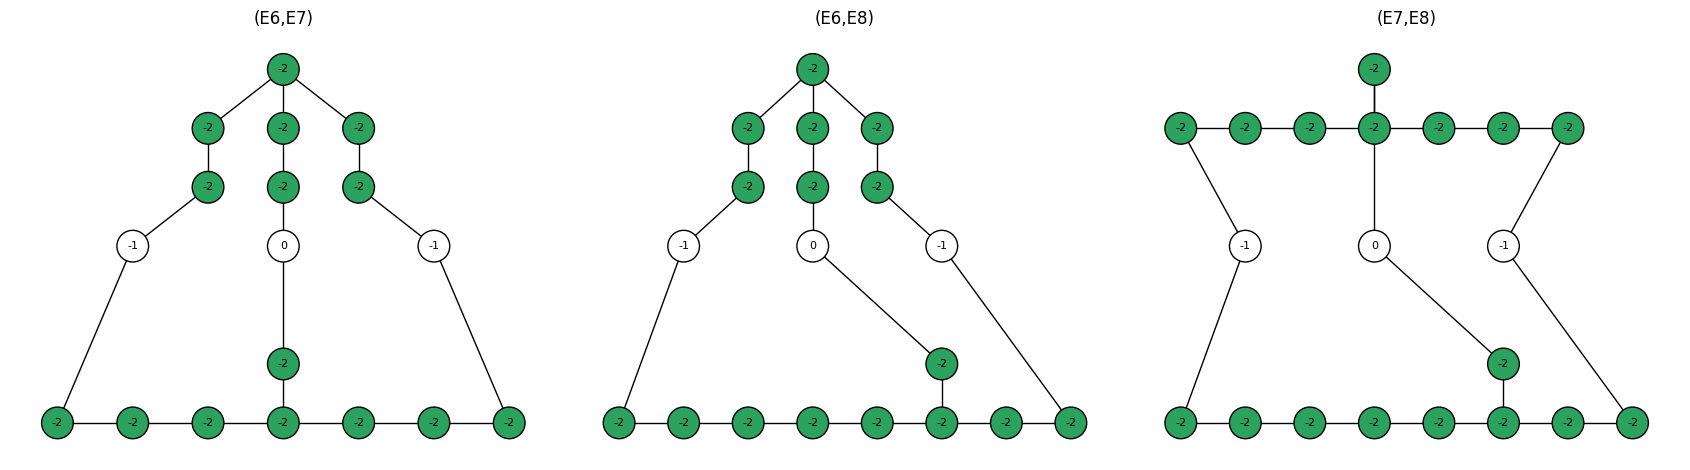

In [8]:
def _add_marked(cfd: CFD, node: str, pos: Tuple[float, float]) -> None:
    cfd.add_curve(node, n=-2, g=0, marked=True, pos=pos)


def add_affine_E6(cfd: CFD, prefix: str, anchor_y: float = 4.0) -> Dict[str, str]:
    coords = {
        "top": (3, anchor_y + 2),
        "lm": (2, anchor_y + 1), "cm": (3, anchor_y + 1), "rm": (4, anchor_y + 1),
        "ll": (2, anchor_y),     "cl": (3, anchor_y),     "rl": (4, anchor_y),
    }
    for k, pos in coords.items():
        _add_marked(cfd, f"{prefix}_{k}", pos)
    for a, b in [("top", "lm"), ("top", "cm"), ("top", "rm"), ("lm", "ll"), ("cm", "cl"), ("rm", "rl")]:
        cfd.add_intersection(f"{prefix}_{a}", f"{prefix}_{b}")
    return {"left": f"{prefix}_ll", "center": f"{prefix}_cl", "right": f"{prefix}_rl"}


def add_affine_E7_row(cfd: CFD, prefix: str, y0: float, branch_index: int = 3) -> Dict[str, str]:
    for i in range(7):
        _add_marked(cfd, f"{prefix}_r{i}", (i, y0))
    _add_marked(cfd, f"{prefix}_branch", (branch_index, y0 + 1))
    for i in range(6):
        cfd.add_intersection(f"{prefix}_r{i}", f"{prefix}_r{i+1}")
    cfd.add_intersection(f"{prefix}_r{branch_index}", f"{prefix}_branch")
    return {"left": f"{prefix}_r0", "center": f"{prefix}_branch", "right": f"{prefix}_r6"}


def add_affine_E8_row(cfd: CFD, prefix: str, y0: float, branch_index: int = 5) -> Dict[str, str]:
    for i in range(8):
        _add_marked(cfd, f"{prefix}_r{i}", (i, y0))
    _add_marked(cfd, f"{prefix}_branch", (branch_index, y0 + 1))
    for i in range(7):
        cfd.add_intersection(f"{prefix}_r{i}", f"{prefix}_r{i+1}")
    cfd.add_intersection(f"{prefix}_r{branch_index}", f"{prefix}_branch")
    return {"left": f"{prefix}_r0", "center": f"{prefix}_branch", "right": f"{prefix}_r7"}


def add_bridge(cfd: CFD, top: Dict[str, str], bottom: Dict[str, str], y: float = 3.0) -> None:
    cfd.add_curve("bridge_L", -1, marked=False, pos=(1, y))
    cfd.add_curve("bridge_Z", 0, marked=False, pos=(3, y))
    cfd.add_curve("bridge_R", -1, marked=False, pos=(5, y))
    cfd.add_intersection(top["left"], "bridge_L")
    cfd.add_intersection(top["center"], "bridge_Z")
    cfd.add_intersection(top["right"], "bridge_R")
    cfd.add_intersection(bottom["left"], "bridge_L")
    cfd.add_intersection(bottom["center"], "bridge_Z")
    cfd.add_intersection(bottom["right"], "bridge_R")


def max_hubner_marginal_cfd(label: str) -> CFD:
    if label == "(E6,E7)":
        cfd = CFD(name=label)
        top = add_affine_E6(cfd, "E6", anchor_y=4)
        bottom = add_affine_E7_row(cfd, "E7", y0=0, branch_index=3)
    elif label == "(E6,E8)":
        cfd = CFD(name=label)
        top = add_affine_E6(cfd, "E6", anchor_y=4)
        bottom = add_affine_E8_row(cfd, "E8", y0=0, branch_index=5)
    elif label == "(E7,E8)":
        cfd = CFD(name=label)
        top = add_affine_E7_row(cfd, "E7", y0=5, branch_index=3)
        bottom = add_affine_E8_row(cfd, "E8", y0=0, branch_index=5)
    else:
        raise ValueError(label)
    add_bridge(cfd, top, bottom, y=3)
    return cfd


marginal_cfds = {label: max_hubner_marginal_cfd(label) for label in CASE_DATA}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (label, cfd) in zip(axes, marginal_cfds.items()):
    cfd.draw(title=label, ax=ax)
plt.tight_layout()


In [9]:
computed_counts = {label: len(enumerate_descendants(cfd)) for label, cfd in marginal_cfds.items()}
reported_counts = {"(E6,E7)": 90, "(E6,E8)": 196, "(E7,E8)": 225}

pd.DataFrame(
    [{"case": k, "computed descendants": computed_counts[k], "reported by Hübner": reported_counts[k]} for k in reported_counts]
).set_index("case")


,computed descendants,reported by Hübner
case,,
"(E6,E7)",90,90
"(E6,E8)",196,196
"(E7,E8)",225,225


In [10]:
assert computed_counts == reported_counts
